# Retail Business Performance & Profitability Analysis  
## Amazon Sales Case Study

**Tools Used:** Python (Pandas, Matplotlib, Seaborn), SQL, Power BI  

**Objective:**  
Analyze Amazon transactional retail data to uncover category-wise performance,
regional trends, and profitability insights to support business decisions.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


In [4]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\jeeva\OneDrive\Desktop\Amazon Sales Performance & Profitability Analysis\raw_data\raw_data_amazon_sales_clean.xlsx.csv"
)

df.head()


C:\Users\jeeva\AppData\Local\Temp\ipykernel_3920\1171635732.py:3: DtypeWarning: Columns (18,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,order_id,order_date,order_status,fulfilment_type,sales_channel,ship-service-level,Style,category,Size,Courier Status,...,currency,sales_amount,ship-city,state,ship-postal-code,country,B2B,fulfilled-by,Unnamed: 19,Unnamed: 20
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,Set,S,NaN,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,FALSE,Easy Ship,NaN,NaN
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,kurta,3XL,Shipped,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,FALSE,Easy Ship,NaN,NaN
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,kurta,XL,Shipped,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,TRUE,NaN,NaN,NaN
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,Western Dress,L,NaN,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,FALSE,Easy Ship,NaN,NaN
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,Top,3XL,Shipped,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,FALSE,NaN,NaN,NaN


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_id            128975 non-null  object        
 1   order_date          128975 non-null  datetime64[ns]
 2   order_status        128975 non-null  object        
 3   fulfilment_type     128975 non-null  object        
 4   sales_channel       128975 non-null  object        
 5   ship-service-level  128975 non-null  object        
 6   Style               128975 non-null  object        
 7   category            128975 non-null  object        
 8   Size                128975 non-null  object        
 9   Courier Status      122103 non-null  object        
 10  quantity            128975 non-null  int64         
 11  currency            121180 non-null  object        
 12  sales_amount        121180 non-null  float64       
 13  ship-city           128942 no

## 4. Data Preparation Summary

At this stage, the dataset has been validated with correct data types.
The `order_date` column is converted to datetime format, and the dataset
is ready for business-level analysis.


In [10]:
df = df.drop(columns=["Unnamed: 19", "Unnamed: 20"])
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_id            128975 non-null  object        
 1   order_date          128975 non-null  datetime64[ns]
 2   order_status        128975 non-null  object        
 3   fulfilment_type     128975 non-null  object        
 4   sales_channel       128975 non-null  object        
 5   ship-service-level  128975 non-null  object        
 6   Style               128975 non-null  object        
 7   category            128975 non-null  object        
 8   Size                128975 non-null  object        
 9   Courier Status      122103 non-null  object        
 10  quantity            128975 non-null  int64         
 11  currency            121180 non-null  object        
 12  sales_amount        121180 non-null  float64       
 13  ship-city           128942 no

## 5. Filtering Cancelled Orders

Cancelled orders do not contribute to revenue. These records are excluded
to ensure accurate sales and profitability analysis.


In [11]:
df = df[df["order_status"].str.lower() != "cancelled"]
df.shape


(110643, 19)

## 6. Feature Engineering

Time-based features are created from the order date to support
trend and seasonality analysis.


In [12]:
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["year_month"] = df["order_date"].dt.to_period("M")

df[["order_date", "year", "month", "year_month"]].head()


,order_date,year,month,year_month
1,2022-04-30,2022,4,2022-04
2,2022-04-30,2022,4,2022-04
4,2022-04-30,2022,4,2022-04
5,2022-04-30,2022,4,2022-04
6,2022-04-30,2022,4,2022-04


## 7. Category-wise Sales Performance

This analysis identifies top-performing product categories based on
total sales contribution.


In [13]:
category_sales = (
    df.groupby("category")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
)

category_sales


category
Set              35731673.0
kurta            19425870.0
Western Dress    10209590.0
Top               4904066.0
Ethnic Dress       732744.0
Blouse             418389.0
Bottom             135453.0
Saree              114694.0
Dupatta               915.0
Name: sales_amount, dtype: float64

### Visualization: Sales by Category


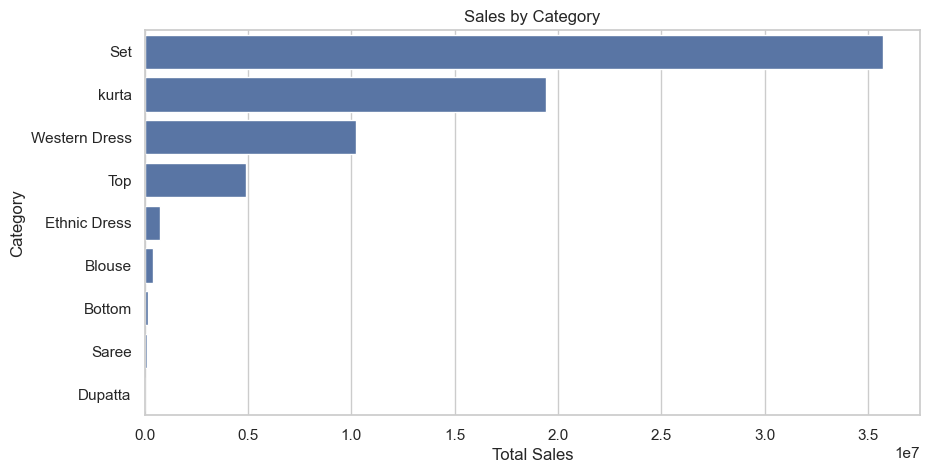

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x=category_sales.values,
    y=category_sales.index
)
plt.title("Sales by Category")
plt.xlabel("Total Sales")
plt.ylabel("Category")
plt.show()


## 8. State-wise Sales Analysis

Analyzing sales distribution across states helps identify
high-performing and underperforming regions.


In [15]:
state_sales = (
    df.groupby("state")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
)

state_sales.head(10)


state
MAHARASHTRA       12224770.0
KARNATAKA          9649981.0
TELANGANA          6290128.0
UTTAR PRADESH      6186656.0
TAMIL NADU         5954349.0
DELHI              3906089.0
KERALA             3377321.0
WEST BENGAL        3207213.0
ANDHRA PRADESH     2882206.0
HARYANA            2654274.0
Name: sales_amount, dtype: float64

### Visualization: Top 10 States by Sales


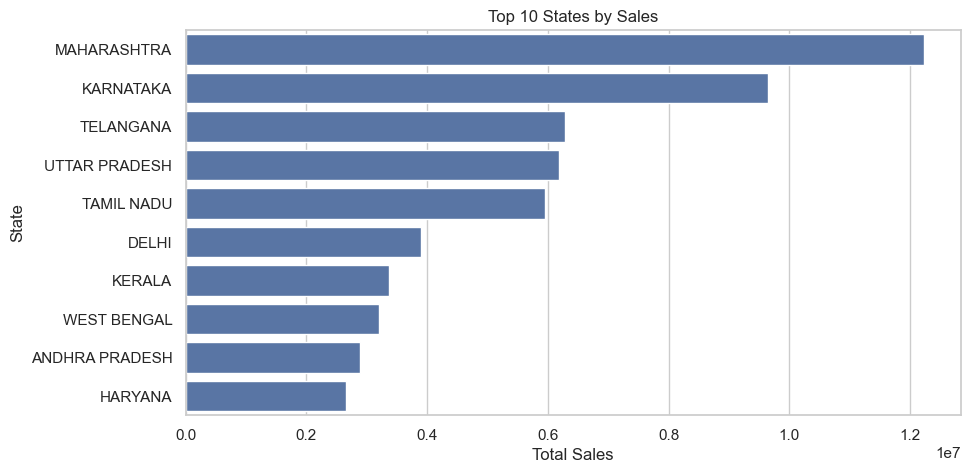

In [16]:
top_states = state_sales.head(10)

sns.barplot(
    x=top_states.values,
    y=top_states.index
)
plt.title("Top 10 States by Sales")
plt.xlabel("Total Sales")
plt.ylabel("State")
plt.show()

## 9. Monthly Sales Trend

Monthly sales trends help understand seasonality
and demand fluctuations over time.


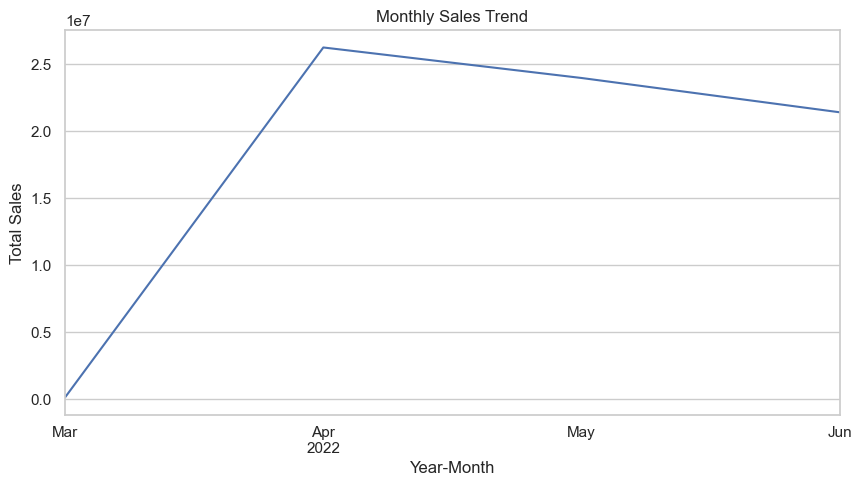

In [17]:
monthly_sales = df.groupby("year_month")["sales_amount"].sum()

monthly_sales.plot(kind="line")
plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Total Sales")
plt.show()


## 10. Key Insights

- A small number of categories contribute to the majority of sales.
- Certain states consistently outperform others in terms of revenue.
- Sales show clear seasonal patterns across months.
- Removing cancelled orders significantly improves revenue accuracy.
